# Exploratory Data Analysis — Finlora Finance Fraud Detection Project

Profiles transaction amount, velocity, device novelty, and cross-border activity by fraud
label, to identify which signals separate fraud from legitimate activity before modeling.

In [1]:
import pandas as pd #Importation pandas
import matplotlib.pyplot as plt #Importation matplotlib

In [2]:
df = pd.read_csv("../data/processed/finlora_cleaned.csv") #Load cleaned dataframe from csv file

In [3]:
df.head(3) #Display first 3 rows of the dataframe

,transaction_id,account_id,account_type,kyc_tier,timestamp,day_of_week,hour_of_day,description,merchant_name,merchant_category,...,device_id,is_new_device,account_age_days,status,is_fraud,account_holder_name,currency_y,account_created_date,personal_spend_baseline_usd,has_device_on_record
0,FLR250216186265,FLR-ACC-100000,Individual,Tier3_Enhanced,2025-02-16 14:55:35,Sunday,14,CNP PURCHASE - BOLT,Bolt,Travel,...,NO_DEVICE_RECORDED,NaN,903,Completed,0,Amaka Okafor,NGN,2022-08-28,63.23,0
1,FLR250423143305,FLR-ACC-100000,Individual,Tier3_Enhanced,2025-04-23 13:35:40,Wednesday,13,WEB PURCHASE - SLACK,Slack,Subscription/SaaS,...,NO_DEVICE_RECORDED,NaN,969,Declined,0,Amaka Okafor,NGN,2022-08-28,63.23,0
2,FLR250424154897,FLR-ACC-100000,Individual,Tier3_Enhanced,2025-04-24 12:30:34,Thursday,12,MOBILE PURCHASE - JUSTRITE SUPERSTORE,Justrite Superstore,Groceries,...,DEV-9055235108,0.0,970,Completed,0,Amaka Okafor,NGN,2022-08-28,63.23,1


In [4]:
df["timestamp"] = pd.to_datetime(df["timestamp"]) #Convert timestamp column to datetime format because it is currently in object format. | CSVs do not support datetime format, so it is converted to object format when saved to CSV. We need to convert it back to datetime format for analysis.

In [5]:
df.shape

(126000, 29)

In [6]:
df['is_fraud'].mean()

np.float64(0.026603174603174604)

In [7]:
df.head() #Display first 5 rows of the dataframe

,transaction_id,account_id,account_type,kyc_tier,timestamp,day_of_week,hour_of_day,description,merchant_name,merchant_category,...,device_id,is_new_device,account_age_days,status,is_fraud,account_holder_name,currency_y,account_created_date,personal_spend_baseline_usd,has_device_on_record
0,FLR250216186265,FLR-ACC-100000,Individual,Tier3_Enhanced,2025-02-16 14:55:35,Sunday,14,CNP PURCHASE - BOLT,Bolt,Travel,...,NO_DEVICE_RECORDED,NaN,903,Completed,0,Amaka Okafor,NGN,2022-08-28,63.23,0
1,FLR250423143305,FLR-ACC-100000,Individual,Tier3_Enhanced,2025-04-23 13:35:40,Wednesday,13,WEB PURCHASE - SLACK,Slack,Subscription/SaaS,...,NO_DEVICE_RECORDED,NaN,969,Declined,0,Amaka Okafor,NGN,2022-08-28,63.23,0
2,FLR250424154897,FLR-ACC-100000,Individual,Tier3_Enhanced,2025-04-24 12:30:34,Thursday,12,MOBILE PURCHASE - JUSTRITE SUPERSTORE,Justrite Superstore,Groceries,...,DEV-9055235108,0.0,970,Completed,0,Amaka Okafor,NGN,2022-08-28,63.23,1
3,FLR250428101772,FLR-ACC-100000,Individual,Tier3_Enhanced,2025-04-28 14:41:59,Monday,14,CNP PURCHASE - ADOBE CREATIVE CLOUD,Adobe Creative Cloud,Subscription/SaaS,...,NO_DEVICE_RECORDED,NaN,974,Completed,0,Amaka Okafor,NGN,2022-08-28,63.23,0
4,FLR250628102827,FLR-ACC-100000,Individual,Tier3_Enhanced,2025-06-28 16:15:47,Saturday,16,MOBILE PURCHASE - APPLE STORE,Apple Store,Electronics,...,DEV-9055235108,0.0,1035,Declined,0,Amaka Okafor,NGN,2022-08-28,63.23,1


Next action below: The code will help groups rows into two categories — is_fraud = 0 (legitimate) and is_fraud = 1 (fraud) — showing count, mean, standard deviation, min, percentiles, and max of amount_to_avg_ratio. My expectation is higher mean/median values for fraudulent transactions, indicating they are larger than typical amounts. Having similar values would mean that amount deviation is not a strong fraud indicator. ON AMOUNT_TO_AVERAGE_RATIO

## Amount-to-average-ratio

In [8]:
df.groupby('is_fraud')['amount_to_avg_ratio'].describe() #described above

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,122648.0,3.980504,61.461151,0.00,0.24,0.95,1.730,11044.22
1,3352.0,152.116811,852.700246,0.01,0.63,6.04,56.525,31762.69


### The median reveals that typical legitimate transactions are about 0.95x the account's normal spend, while typical fraud transactions are 6.04x, showing a significant difference in transaction size.

### The mean is significantly higher than the median in both groups, especially in fraud (152 vs. 6), indicating extreme outliers. A few fraud transactions at over 20,000x are skewing the mean, while the median better represents typical values. A feature like amount_to_avg_ratio is important for modelling and worthy of note to understand that Logistic Regression is highly sensitive to scale and outliers. 

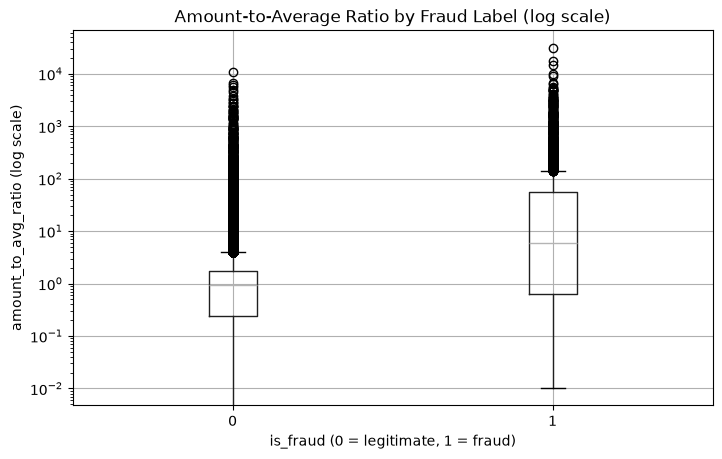

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
df.boxplot(column='amount_to_avg_ratio', by='is_fraud', ax=ax)
ax.set_yscale('log')
ax.set_title('Amount-to-Average Ratio by Fraud Label (log scale)')
ax.set_xlabel('is_fraud (0 = legitimate, 1 = fraud)')
ax.set_ylabel('amount_to_avg_ratio (log scale)')
plt.suptitle('')  # removes the default auto-title that pandas adds
plt.show()

"Fraud transactions show a consistently higher amount-to-average ratio than legitimate ones — the entire distribution shifts upward, not just a few extreme outliers."

## Velocity

#### Fraud may occur alongside multiple transactions. Analyzing the last hour can reveal unusual spikes in activity, indicating bursts rather than isolated events, though some transactions may still appear solitary.

Next action below: The code will help groups rows into two categories — is_fraud = 0 (legitimate) and is_fraud = 1 (fraud) — showing count, mean, standard deviation, min, percentiles, and max of amount_to_avg_ratio. My expectation is higher mean/median values for fraudulent transactions, indicating they are larger than typical amounts. Having similar values would mean that amount deviation is not a strong fraud indicator. ON TRANSACTION_VELOCITY_1H

In [10]:
df.groupby('is_fraud')['transaction_velocity_1h'].describe() #described above

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,122648.0,0.000905,0.031655,0.0,0.0,0.0,0.0,2.0
1,3352.0,0.396480,0.518266,0.0,0.0,0.0,1.0,3.0


### The fraud group's mean (0.396) is about 440x the legitimate group's mean (0.0009). In the 75th percentile, 75% of legitimate transactions have a velocity of 0, while for fraud, it's 1 — indicating at least 25% of fraud transactions occur within the same hour.

### Finding: velocity is a significant fraud indicator; rare non-zero values are mostly in fraud. Reflective of Real-world pattern where stolen accounts often see rapid transactions, unlike typical cardholders.

In [11]:
print(df['transaction_velocity_1h'].value_counts().sort_index().head(10)) # Transactions by velocity 0, 1, 2, 3

transaction_velocity_1h
0    124614
1      1333
2        52
3         1
Name: count, dtype: int64


In [12]:
print(pd.crosstab(df['transaction_velocity_1h'], df['is_fraud'], normalize='index')) # Converting each row into velocity percentages that sum to 100% (or 1.0), instead of raw counts by 0(legitimate) and 1(fraud).

is_fraud                        0         1
transaction_velocity_1h                    
0                        0.983381  0.016619
1                        0.074269  0.925731
2                        0.115385  0.884615
3                        0.000000  1.000000


note:
The pattern "any velocity > 0 = almost certainly fraud" is unusual, even for strong fraud features. It’s plausible, but is it realistic? Nevertheless, we go with the data and not intuition.

Velocity isn’t leakage, unlike status. It's calculated in real-time from transaction timings, while status resolves to "Reversed" later. Hence, velocity is a valid feature, eventhough it is mostly unpredicatable.

### Device (is_new_device or has_device_on record)

### Recall earlier that device_id had ~11% missing values, unrelated to channel. We created a clean flag, has_device_on_record, and left is_new_device unchanged.

In [13]:
print(pd.crosstab(df['has_device_on_record'], df['is_fraud'], normalize='index'))
#does having no device on record have relationship with fraud? is there a correlation | normalize='index' means that each row is normalized and will sum to 1.0 (or 100%)

is_fraud                     0         1
has_device_on_record                    
0                     0.976071  0.023929
1                     0.973054  0.026946


The two rows are nearly identical, both around a ~2.66% fraud rate. Recording a device has little impact.

Finding: Having no device on record isn't a meaningful fraud signal. This aligns with our earlier hypothesis that the missingness appears random and is not linked to fraud.

In [14]:
print(df['is_new_device'].isnull().sum())  # confirm this only has nulls where has_device_on_record == 0
print(pd.crosstab(df['is_new_device'], df['is_fraud'], normalize='index'))
#This is the more interesting question: among transactions that do have a device on record, does it being a new, 
# ...previously-unseen device (as opposed to one the account has used before) correlate with fraud?

14334
is_fraud              0         1
is_new_device                    
0.0            0.974195  0.025805
1.0            0.941463  0.058537


#### A known device has a baseline fraud rate of ~2.6%, while a new device raises it to ~5.9%. This is a moderate signal; it's notably different from the baseline but not as drastic as with velocity changes. The new device alone is not sufficient to reliably flag transactions, as 94% of them remain legitimate. This feature is valuable when combined with other signals but independently insufficient.